<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/GR003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mercury orbital parameters:
  Perihelion: r=0.3073 AU, v=59.01 km/s
  Aphelion: r=0.4667 AU, v=38.85 km/s
  Semi-major axis: 0.3870 AU
  Eccentricity: 0.2060

Schwarzschild radius: 2953.98 m
GR parameter: 5.102e-08

Simulation: spacing=0.007740 AU, dt=0.422 hrs

Starting at PERIHELION:
  Position: r=39.70 lattice units = 0.3073 AU
  Velocity: v=0.077475 lattice units/step = 59.01 km/s
  Energy: -1.146484e+09 J/kg (expected -1.146484e+09)
  Match: 0.000000%
  Initial acceleration: 1.253686e-04 lattice units/step²

Running simulation...
  Step 10000: r=0.3073 AU, v=59.01 km/s
  Step 20000: r=0.3073 AU, v=59.01 km/s
  Step 30000: r=0.3073 AU, v=59.01 km/s
  Step 40000: r=0.3073 AU, v=59.01 km/s
  Step 50000: r=0.3073 AU, v=59.00 km/s
  Step 60000: r=0.3074 AU, v=59.00 km/s
  Step 70000: r=0.3074 AU, v=58.99 km/s
  Step 80000: r=0.3074 AU, v=58.99 km/s
  Step 90000: r=0.3075 AU, v=58.98 km/s
  Step 100000: r=0.3075 AU, v=58.97 km/s
  Step 110000: r=0.3076 AU, v=58.96 km/s
  Step 120000: r=

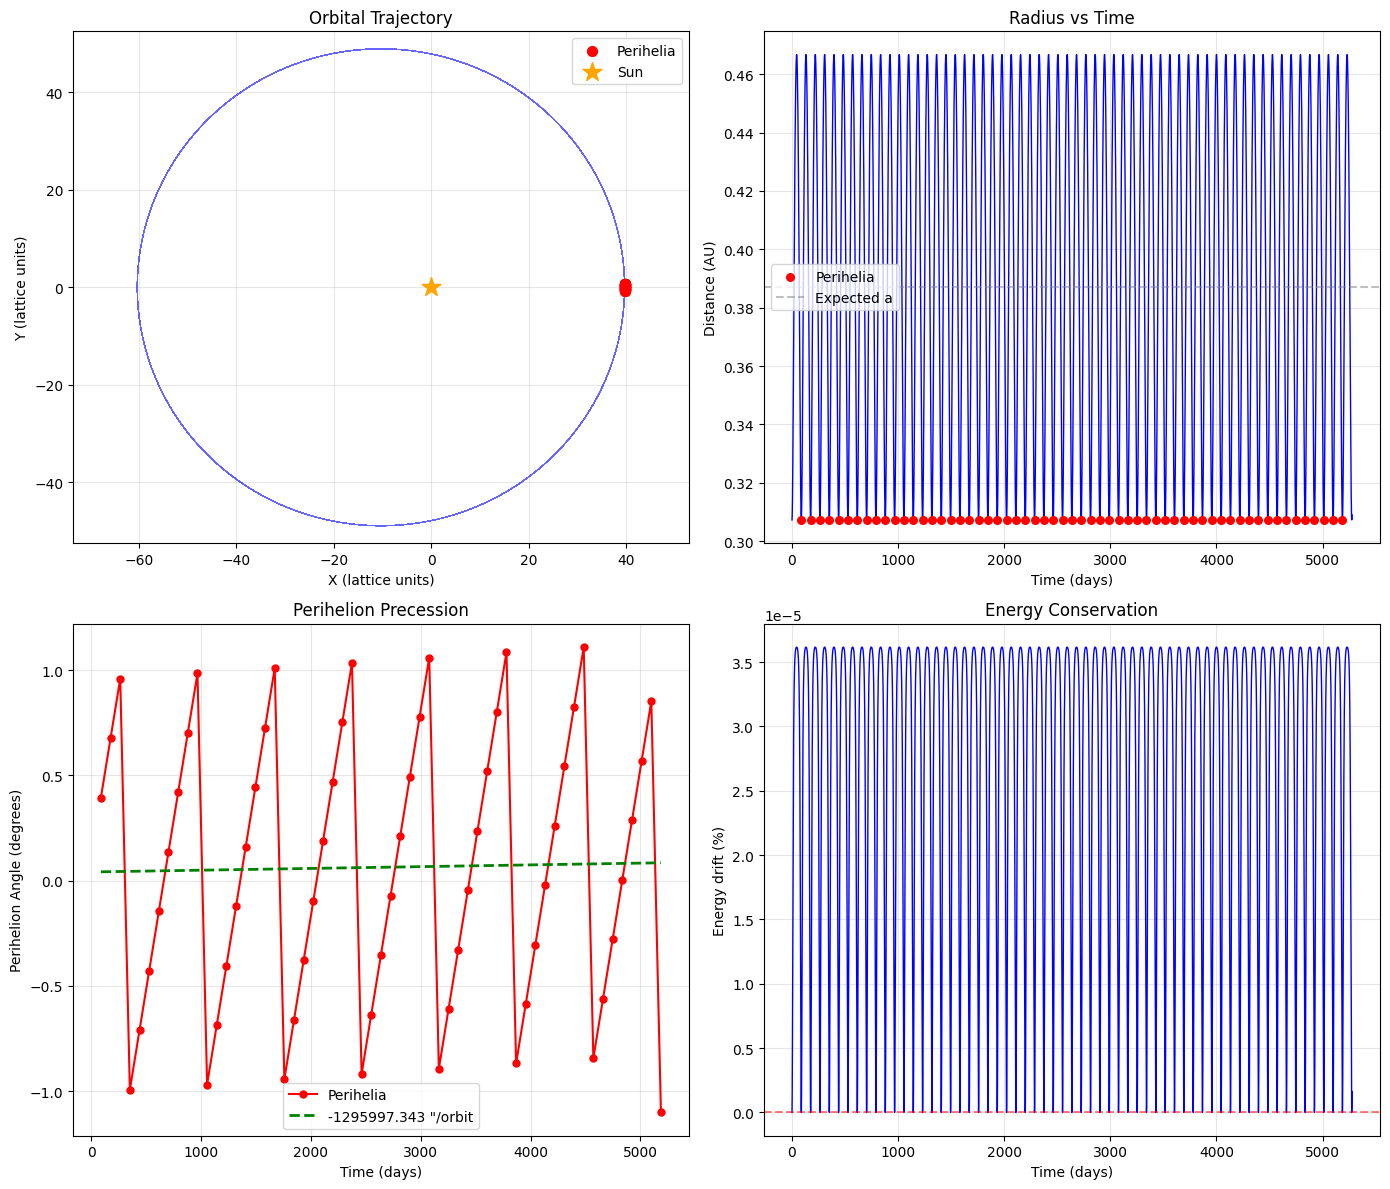


Done!


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Physical constants (SI)
G = 6.67430e-11
M_sun = 1.989e30
c = 2.998e8
AU = 1.496e11

# Mercury parameters
a_mercury = 0.387 * AU
e_mercury = 0.206
period_mercury = 87.969 * 24 * 3600

r_peri = a_mercury * (1 - e_mercury)
r_aph = a_mercury * (1 + e_mercury)

# Velocities from vis-viva
v_peri = np.sqrt(G * M_sun * (2/r_peri - 1/a_mercury))
v_aph = np.sqrt(G * M_sun * (2/r_aph - 1/a_mercury))

print("Mercury orbital parameters:")
print(f"  Perihelion: r={r_peri/AU:.4f} AU, v={v_peri/1000:.2f} km/s")
print(f"  Aphelion: r={r_aph/AU:.4f} AU, v={v_aph/1000:.2f} km/s")
print(f"  Semi-major axis: {a_mercury/AU:.4f} AU")
print(f"  Eccentricity: {e_mercury:.4f}")

r_s = 2 * G * M_sun / c**2
print(f"\nSchwarzschild radius: {r_s:.2f} m")
print(f"GR parameter: {r_s/a_mercury:.3e}")

# Simulation setup
spacing = a_mercury / 50
dt = period_mercury / 5000
steps = 300000

print(f"\nSimulation: spacing={spacing/AU:.6f} AU, dt={dt/3600:.3f} hrs")

# Start at PERIHELION (easier - faster velocity, smaller orbit)
center = np.array([150.0, 150.0, 150.0])
r_start_phys = r_peri
r_start = r_start_phys / spacing

orbit_pos = np.array([center[0] + r_start, center[1], center[2]])
v_start = v_peri * dt / spacing
orbit_vel = np.array([0.0, v_start, 0.0])

print(f"\nStarting at PERIHELION:")
print(f"  Position: r={r_start:.2f} lattice units = {r_start_phys/AU:.4f} AU")
print(f"  Velocity: v={v_start:.6f} lattice units/step = {v_peri/1000:.2f} km/s")

# Verify energy
E_init = 0.5 * v_peri**2 - G * M_sun / r_start_phys
E_expected = -G * M_sun / (2 * a_mercury)
print(f"  Energy: {E_init:.6e} J/kg (expected {E_expected:.6e})")
print(f"  Match: {abs(E_init-E_expected)/abs(E_expected)*100:.6f}%")

# Angular momentum for GR correction
L_mercury = r_peri * v_peri  # Will be conserved

def compute_acceleration(pos, vel, center, spacing, dt):
    """
    Compute acceleration with GR correction.
    Only applies REAL forces - no artificial centrifugal term!
    The centrifugal effect arises naturally from orbital motion.
    """
    r_vec = (pos - center) * spacing
    v_vec = vel * spacing / dt
    r = np.linalg.norm(r_vec)

    if r < spacing * 0.5:
        return np.zeros(3)

    r_hat = r_vec / r

    # Newtonian gravity (REAL force)
    F_newton = -G * M_sun / r**2 * r_hat

    # GR correction (REAL additional force)
    # This is the extra attraction that causes perihelion precession
    # Standard formula: F_GR = -3GM L²/(c²r⁴) radial
    L_vec = np.cross(r_vec, v_vec)
    L = np.linalg.norm(L_vec)
    F_gr = -3 * G * M_sun * L**2 / (c**2 * r**4) * r_hat

    # Total force per unit mass
    F_total = F_newton + F_gr

    # Convert to lattice acceleration
    return F_total * dt**2 / spacing

# Storage
positions = []
r_list = []
angles = []
energies = []
angular_momenta = []

# Initial acceleration
acc = compute_acceleration(orbit_pos, orbit_vel, center, spacing, dt)

print(f"  Initial acceleration: {np.linalg.norm(acc):.6e} lattice units/step²\n")
print("Running simulation...")

for t in range(steps):
    # Velocity Verlet
    orbit_pos += orbit_vel + 0.5 * acc
    acc_new = compute_acceleration(orbit_pos, orbit_vel, center, spacing, dt)
    orbit_vel += 0.5 * (acc + acc_new)
    acc = acc_new

    # Store every 20 steps
    if t % 20 == 0:
        positions.append(orbit_pos.copy())

        r_phys = np.linalg.norm(orbit_pos - center) * spacing
        r_list.append(r_phys)

        angle = np.arctan2(orbit_pos[1] - center[1], orbit_pos[0] - center[0])
        angles.append(angle)

        v_phys = np.linalg.norm(orbit_vel) * spacing / dt
        KE = 0.5 * v_phys**2
        PE = -G * M_sun / r_phys
        energies.append(KE + PE)

        # Check angular momentum
        r_vec = (orbit_pos - center) * spacing
        v_vec = orbit_vel * spacing / dt
        L_vec = np.cross(r_vec, v_vec)
        angular_momenta.append(np.linalg.norm(L_vec))

    if t % 10000 == 0 and t > 0:
        r_now = np.linalg.norm(orbit_pos - center) * spacing
        v_now = np.linalg.norm(orbit_vel) * spacing / dt
        print(f"  Step {t}: r={r_now/AU:.4f} AU, v={v_now/1000:.2f} km/s")

print(f"\nCompleted! Stored {len(positions)} positions")

# Analysis
positions = np.array(positions)
r_array = np.array(r_list)
angles_array = np.array(angles)
E_array = np.array(energies)
L_array = np.array(angular_momenta)

peri_indices, _ = find_peaks(-r_array, distance=200, prominence=0.01*a_mercury)

print(f"\n=== RESULTS ===")
print(f"Orbit:")
print(f"  Perihelia found: {len(peri_indices)}")
print(f"  r_min: {np.min(r_array)/AU:.4f} AU (expected {r_peri/AU:.4f})")
print(f"  r_max: {np.max(r_array)/AU:.4f} AU (expected {r_aph/AU:.4f})")

ecc = (np.max(r_array) - np.min(r_array)) / (np.max(r_array) + np.min(r_array))
a_measured = (np.max(r_array) + np.min(r_array)) / 2

print(f"  Eccentricity: {ecc:.4f} (expected {e_mercury:.4f})")
print(f"  Semi-major axis: {a_measured/AU:.4f} AU (expected {a_mercury/AU:.4f})")

if len(peri_indices) >= 3:
    peri_angles = angles_array[peri_indices]
    unwrapped = np.unwrap(peri_angles)
    coeffs = np.polyfit(np.arange(len(unwrapped)), unwrapped, 1)
    prec_per_orbit = coeffs[0] - 2*np.pi
    orbits_per_century = 100 * 365.25 / (period_mercury / (24*3600))
    prec_arcsec = prec_per_orbit * (180/np.pi * 3600) * orbits_per_century

    print(f"\nPrecession:")
    print(f"  Per orbit: {prec_per_orbit*180/np.pi*3600:.6f} arcsec")
    print(f"  Per century: {prec_arcsec:.2f} arcsec")
    print(f"  GR prediction: 43.0 arcsec")
    if abs(prec_arcsec) < 1000:
        print(f"  Error: {abs(prec_arcsec - 43)/43*100:.1f}%")

E_drift = (E_array[-1] - E_array[0]) / abs(E_array[0]) * 100
L_drift = (L_array[-1] - L_array[0]) / L_array[0] * 100

print(f"\nConservation:")
print(f"  Energy drift: {E_drift:.2f}%")
print(f"  Energy std: {np.std(E_array)/abs(np.mean(E_array))*100:.2f}%")
print(f"  L drift: {L_drift:.4f}%")
print(f"  L std: {np.std(L_array)/np.mean(L_array)*100:.4f}%")

# Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

ax = axes[0, 0]
ax.plot(positions[:, 0] - center[0], positions[:, 1] - center[1], 'b-', lw=0.5, alpha=0.6)
if len(peri_indices) > 0:
    ax.scatter(positions[peri_indices, 0] - center[0],
               positions[peri_indices, 1] - center[1],
               c='red', s=50, label='Perihelia', zorder=5)
ax.scatter(0, 0, c='orange', s=200, marker='*', label='Sun', zorder=10)
ax.set_xlabel('X (lattice units)')
ax.set_ylabel('Y (lattice units)')
ax.set_title('Orbital Trajectory')
ax.legend()
ax.axis('equal')
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
time_days = np.arange(len(r_list)) * 20 * dt / (24*3600)
ax.plot(time_days, r_array/AU, 'b-', lw=1)
if len(peri_indices) > 0:
    ax.scatter(time_days[peri_indices], r_array[peri_indices]/AU,
               c='red', s=30, label='Perihelia', zorder=5)
ax.axhline(a_mercury/AU, c='gray', ls='--', alpha=0.5, label='Expected a')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Distance (AU)')
ax.set_title('Radius vs Time')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
if len(peri_indices) >= 3:
    peri_times = time_days[peri_indices]
    ax.plot(peri_times, unwrapped*180/np.pi, 'ro-', ms=5, label='Perihelia')
    fit_angles = coeffs[0] * np.arange(len(unwrapped)) + coeffs[1]
    ax.plot(peri_times, fit_angles*180/np.pi, 'g--', lw=2,
            label=f'{prec_per_orbit*180/np.pi*3600:.3f} "/orbit')
    ax.set_xlabel('Time (days)')
    ax.set_ylabel('Perihelion Angle (degrees)')
    ax.set_title('Perihelion Precession')
    ax.legend()
    ax.grid(True, alpha=0.3)

ax = axes[1, 1]
E_rel = (E_array - E_array[0]) / abs(E_array[0]) * 100
ax.plot(time_days, E_rel, 'b-', lw=1)
ax.axhline(0, c='red', ls='--', alpha=0.5)
ax.set_xlabel('Time (days)')
ax.set_ylabel('Energy drift (%)')
ax.set_title('Energy Conservation')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mercury_gr_final.png', dpi=150)
plt.show()

print("\nDone!")